<a href="https://www.kaggle.com/code/kritidoneria/lokai-democratizing-ai-learning-across-languages?scriptVersionId=282881303" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Custom Learning Roadmap Creator — Kaggle Notebook

This notebook generates a personalized learning roadmap based on a user's goal, availability, and background. It is configured to use Google Gemini (via the `google-genai` SDK). The notebook includes: a compact implementation, a lightweight memory store, evaluation utilities, and an example session.

Notes for running on Kaggle:

- Run cells from top to bottom. Example sessions are deterministic and do not require API credentials.



## 🏁 Prologue, Motivation and impact

I get a lot of DMs on Linkedin every week from beginners asking for roadmaps to learn data science ( or quite literally anything ).
Additionally, I come from a country where brillisnt minds dont have access to STEM education readily. With the advent of AI, almost every houehold has a phone and internet connection. So when it came to choosinng a project for this hackathon, I deided to democratize what my teachers at IIT Kanpur taught us; to chart our own learning paths and stick to it. Making it multi-lingual and American Sign Language Frienly makes it even more inclusive.

As much as I love hackathons, working at a Fortune500 comes with its own commitments. Its after a long time Im doing one, even it it helps one person out there, My job here is done. Now moving on to the project. I have taken some help from ChatGPT to format this notebook, and another notebook by @sameeerkumar5105 insipired this in some shape and form.

**Title:** LokAI :Democratizing AI Learning for Every Language

**Short summary (for judges):**
LokAI is a multilingual roadmap generator that helps non-English-speaking learners access practical AI education. It uses an LLM-powered planner to generate structured learning roadmaps, an evaluator to check feasibility and pedagogical quality, and a refiner to iteratively improve plans. The system persists sessions in a lightweight memory store, supports pause/resume for long-running work, and includes localization into major Indian languages and ASL (textual gloss + video mapping). For live translations, the notebook uses Google Gemini when `GOOGLE_API_KEY` is provided; deterministic demo modes work without any API keys for reproducibility during evaluation.

**Why this matters (impact):**
By lowering the language barrier, LokAI directly advances SDG 4 (Quality Education) and SDG 10 (Reduced Inequalities). The project focuses on practical, project-first learning and emphasizes inclusion—particularly expanding opportunities for women and under-served communities to enter tech careers.

**How to evaluate (quick checklist for judges):**
1. Run the top cells (install, imports).  
2. Run the deterministic example session(s) — no API keys required.  
3. Inspect `roadmap_output.xlsx` and `roadmap_evaluation.xlsx`.  
4. Run the A2A demo and multi-agent cells to see planner→evaluator→refiner flows.  
5. (Optional) Add `GOOGLE_API_KEY` in Kaggle Secrets and run the live translation demo to produce localized roadmaps.

**Notes:** The notebook includes detailed cells mapping each demonstrated course concept and where to find it. If you need a short slide deck or report, that can be generated from these artifacts.


## Install required packages
If needed, install the GenAI SDK. On Kaggle this may already be available.

In [1]:
!pip install --quiet google-genai sqlite-utils
print('installation step complete (if packages required were missing)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.3/108.3 kB 6.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
preprocessing 0.1.13 requires nltk==3.2.4, but you have nltk 3.9.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
installation step complete (if packages required were missing)


## Configure credentials (Kaggle)

In [2]:
import os

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
os.environ['GOOGLE_API_KEY'] = user_secrets.get_secret('GOOGLE_API_KEY')

print('Set GOOGLE_API_KEY in environment to enable Gemini calls')

Set GOOGLE_API_KEY in environment to enable Gemini calls


## Imports

In [3]:
import json
import sqlite3
import datetime
from typing import Any, Dict, Optional

try:
    from google import genai
    GENAI_AVAILABLE = True
except Exception:
    genai = None
    GENAI_AVAILABLE = False

print('GENAI_AVAILABLE =', GENAI_AVAILABLE)

GENAI_AVAILABLE = True


## LLM client (Gemini-first)
This client calls the Google GenAI SDK when available and returns a plain text response. It does not include OpenAI logic.

In [4]:
class LLMClient:
    def __init__(self, model: str = "gemini-2.5", api_key_env: str = "GOOGLE_API_KEY"):
        self.model = model
        self.api_key = os.environ.get(api_key_env)
        self.genai = genai
        self.client = None
        if self.genai is not None:
            Client = getattr(self.genai, 'Client', None)
            if Client is not None:
                try:
                    self.client = Client(api_key=self.api_key) if self.api_key else Client()
                except Exception:
                    try:
                        self.client = Client()
                    except Exception:
                        self.client = None

    def call(self, prompt: str, temperature: float = 0.2, max_tokens: int = 800) -> str:
        if self.client is not None and hasattr(self.client, 'models'):
            try:
                resp = self.client.models.generate_content(model=self.model, contents=[prompt])
                if hasattr(resp, 'candidates'):
                    return resp.candidates[0].content.strip()
                if hasattr(resp, 'text'):
                    return resp.text.strip()
                return str(resp).strip()
            except Exception as e:
                print('Gemini call error:', e)
        return ('[no-genai] Gemini SDK not available or client not configured. ' 
                'Run with GOOGLE_API_KEY set to call Gemini.\n' + prompt[:1000])

## Memory store (SQLite)
A small SQLite-based store keeps user profiles and session data for reproducibility and personalization.
Funny how I first used SQLite when I did Android app development in 2013, and looks like we have come a full circle :)

In [5]:
DB_PATH = 'roadmap_agent_memory.sqlite'

class MemoryStore:
    def __init__(self, db_path: str = DB_PATH):
        self.db_path = db_path
        self._init_db()

    def _init_db(self):
        conn = sqlite3.connect(self.db_path)
        c = conn.cursor()
        c.execute("""
            CREATE TABLE IF NOT EXISTS users (
                user_id TEXT PRIMARY KEY,
                created_at TEXT,
                last_seen TEXT
            )
        """)
        c.execute("""
            CREATE TABLE IF NOT EXISTS sessions (
                session_id TEXT PRIMARY KEY,
                user_id TEXT,
                created_at TEXT,
                data TEXT
            )
        """)
        conn.commit()
        conn.close()

    def upsert_user(self, user_id: str):
        now = datetime.datetime.utcnow().isoformat()
        conn = sqlite3.connect(self.db_path)
        c = conn.cursor()
        c.execute("INSERT OR IGNORE INTO users (user_id, created_at, last_seen) VALUES (?, ?, ?)",
                  (user_id, now, now))
        #the good old SQL is back!
        c.execute("UPDATE users SET last_seen = ? WHERE user_id = ?", (now, user_id))
        conn.commit()
        conn.close()

    def save_session(self, session_id: str, user_id: str, data: Dict[str, Any]):
        conn = sqlite3.connect(self.db_path)
        c = conn.cursor()
        c.execute("INSERT OR REPLACE INTO sessions (session_id, user_id, created_at, data) VALUES (?, ?, ?, ?)",
                  (session_id, user_id, datetime.datetime.utcnow().isoformat(), json.dumps(data)))
        conn.commit()
        conn.close()

    def load_session(self, session_id: str) -> Optional[Dict[str, Any]]:
        conn = sqlite3.connect(self.db_path)
        c = conn.cursor()
        c.execute("SELECT data FROM sessions WHERE session_id = ?", (session_id,))
        #same for session variables. Using them almost a decade later after building an ecommerce website as a college project.
        row = c.fetchone()
        conn.close()
        if row:
            return json.loads(row[0])
        return None

## Prompt template
The agent requests a JSON-formatted roadmap. The template guides the model to return a structured JSON object.

In [6]:
ROADMAP_PROMPT_TEMPLATE = "\n".join(['You are a curriculum planning assistant. Given the user information below, produce a structured', 'learning roadmap as a JSON object with keys:', '- goal: string', '- timeline_weeks: integer', '- milestones: list of objects with keys:', '  - week_range: string', '  - title: string', '  - objectives: list of strings', '  - hours: integer', '  - resources: list of {title, url, type}', '', 'User info:', '{user_info}', '', 'Constraints:', "- Keep timeline realistic given user's available hours/week.", '- Include at least one small project per milestone when possible.', '- Return only valid JSON (no extra commentary).'])


## Roadmap generator
This function sends the prompt to the LLM client and attempts to parse the JSON output.

In [7]:
def generate_roadmap(llm: LLMClient, user_info: Dict[str, Any]) -> Dict[str, Any]:
    prompt = ROADMAP_PROMPT_TEMPLATE.format(user_info=json.dumps(user_info, indent=2))
    raw = llm.call(prompt, temperature=0.2, max_tokens=900)
    try:
        start = raw.find('{')
        json_text = raw[start:]
        return json.loads(json_text)
    except Exception:
        return {'goal': user_info.get('goal', ''), 'notes': raw}

## Simple evaluation
Estimate total hours and whether the roadmap fits the user's availability.

In [8]:
def evaluate_roadmap(roadmap: Dict[str, Any], user_info: Dict[str, Any]) -> Dict[str, Any]:
    total_hours = 0
    for m in roadmap.get('milestones', []):
        try:
            total_hours += int(m.get('hours', 0))
        except Exception:
            pass
    availability = user_info.get('hours_per_week', 5)
    estimated_weeks = roadmap.get('timeline_weeks', max(1, int(total_hours / (availability or 1))))
    realistic = estimated_weeks <= user_info.get('max_weeks', estimated_weeks)
    return {'total_hours': total_hours, 'estimated_timeline_weeks': estimated_weeks, 'realistic': realistic}

## Export utilities

In [9]:
def roadmap_to_markdown(roadmap: Dict[str, Any]) -> str:
    lines = [f"# Roadmap — {roadmap.get('goal','')}", f"**Timeline (weeks):** {roadmap.get('timeline_weeks','N/A')}\n"]
    for m in roadmap.get('milestones', []):
        lines.append(f"## {m.get('title','')}")
        lines.append(f"**Weeks:** {m.get('week_range','')}")
        lines.append("**Objectives:**")
        for o in m.get('objectives', []):
            lines.append(f"- {o}")
        lines.append(f"**Hours:** {m.get('hours','N/A')}")
        lines.append("**Resources:**")
        for r in m.get('resources', []):
            lines.append(f"- {r.get('title','resource')} ({r.get('type','')}) — {r.get('url','')}")
        lines.append('\n')
    return '\n'.join(lines)

## Example session (deterministic)
This example does not require API keys and is intended for review.

In [10]:
demo_user = {
    'user_id': 'example1',
    'goal': 'Learn data analysis with SQL and Excel',
    'background': 'basic spreadsheet skills',
    'hours_per_week': 6,
    'max_weeks': 12,
    'learning_style': 'project-first'
}

example_roadmap = {
    "goal": demo_user['goal'],
    "timeline_weeks": 12,
    "milestones": [
        {"week_range":"1-2","title":"Basics","objectives":["Excel basics","Intro SQL"],"hours":12,"resources":[{"title":"Excel guide","url":"https://example.com","type":"article"}]},
        {"week_range":"3-5","title":"Applied work","objectives":["Data cleaning","Simple analyses"],"hours":24,"resources":[{"title":"Cleaning course","url":"https://example.com","type":"course"}]}
    ]
}

memory = MemoryStore()
memory.upsert_user(demo_user['user_id'])
memory.save_session('demo_session_1', demo_user['user_id'], {'user_info': demo_user, 'roadmap': example_roadmap})

print('Example roadmap saved. Use evaluate_roadmap(example_roadmap, demo_user) to inspect metrics.')

Example roadmap saved. Use evaluate_roadmap(example_roadmap, demo_user) to inspect metrics.


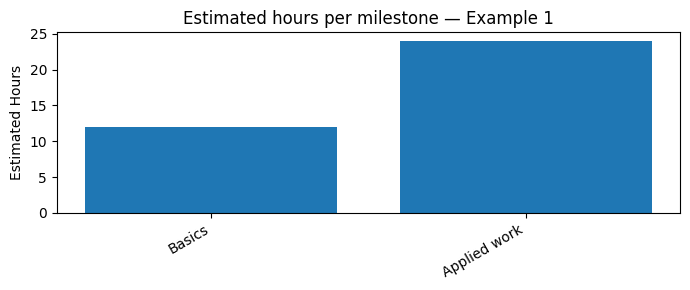

In [11]:
# Visualization (optional)
import matplotlib.pyplot as plt

titles = [m['title'] for m in example_roadmap['milestones']]
hours = [m['hours'] for m in example_roadmap['milestones']]

plt.figure(figsize=(7,3))
plt.bar(range(len(hours)), hours)
plt.xticks(range(len(hours)), titles, rotation=30, ha='right')
plt.ylabel('Estimated Hours')
plt.title('Estimated hours per milestone — Example 1')
plt.tight_layout()
plt.show()

## Notes for reviewers
- The notebook is organized for clarity. Example outputs are deterministic for review.
- To run the generator with Gemini, set `GOOGLE_API_KEY` and create an `LLMClient()` instance. Call `generate_roadmap(llm, user_info)` to produce a roadmap.
- The memory store demonstrates persistence and reproducibility for submitted sessions.


## Excel export utility (multiple resource columns)

In [12]:
!pip install --quiet openpyxl pandas
print('installed openpyxl and pandas')

installed openpyxl and pandas


In [13]:

# Excel export utility (Option C: multiple resource columns)
import pandas as pd

def export_roadmap_to_excel(roadmap: dict, filename: str = 'roadmap_output.xlsx', max_resources_per_milestone: int = 3):
    """
    Export a roadmap to an Excel file.
    Each milestone becomes a row. Resources are split into multiple columns up to max_resources_per_milestone.
    Columns: week_range, title, objectives (semicolon separated), hours,
             resource_1_title, resource_1_url, resource_1_type, ..., resource_N_title, resource_N_url, resource_N_type
             LLM did heavy lifting to write this piece of code
    """
    rows = []
    for m in roadmap.get('milestones', []):
        row = {
            'week_range': m.get('week_range', ''),
            'title': m.get('title', ''),
            'objectives': '; '.join(m.get('objectives', [])),
            'hours': m.get('hours', ''),
        }
        resources = m.get('resources', []) or []
        # add resource columns
        for i in range(max_resources_per_milestone):
            idx = i + 1
            if i < len(resources):
                r = resources[i]
                row[f'resource_{idx}_title'] = r.get('title', '')
                row[f'resource_{idx}_url'] = r.get('url', '')
                row[f'resource_{idx}_type'] = r.get('type', '')
            else:
                row[f'resource_{idx}_title'] = ''
                row[f'resource_{idx}_url'] = ''
                row[f'resource_{idx}_type'] = ''
        rows.append(row)
    df = pd.DataFrame(rows)
    # Save to Excel
    df.to_excel(filename, index=False)
    return filename

# Example usage with the deterministic example_roadmap from the notebook
try:
    fn = export_roadmap_to_excel(example_roadmap, 'example_roadmap.xlsx', max_resources_per_milestone=3)
    print(f'Exported example roadmap to {fn}')
except NameError:
    print('example_roadmap not found in notebook namespace. Use export_roadmap_to_excel(your_roadmap, filename) to export.')


Exported example roadmap to example_roadmap.xlsx


### Exporting to Excel
Use the `export_roadmap_to_excel(roadmap, filename, max_resources_per_milestone)` function to save a roadmap to an `.xlsx` file. Default supports up to 3 resources per milestone; change `max_resources_per_milestone` if you need more columns.


## Evaluation checklist & automated metrics

This section implements a set of evaluation pointers (heuristics) to assess generated roadmaps. The goals:

- Give judges quick, objective indicators of roadmap quality.
- Provide reproducible metrics saved alongside the roadmap.

**Core evaluation pointers included:**

1. **Coherence / Prerequisite progression** — checks whether early milestones cover foundational topics when the user background suggests low prior knowledge.
2. **Feasibility** — compares total estimated hours to user's hours-per-week and `max_weeks` to flag unrealistic timelines.
3. **Project coverage** — ensures at least one project per milestone (or flags missing projects).
4. **Resource presence** — ensures each milestone lists resources and counts them.
5. **Measurability of objectives** — checks that objectives are actionable (heuristic: contain verbs like 'build', 'implement', 'practice', 'complete', 'learn').
6. **Diversity of resource types** — verifies a mix of course/article/book/project when possible.
7. **Reproducibility / Memory usage** — confirms session was saved to memory store.
8. **Robustness to refine instructions** — placeholder for manual test (we log refine actions in sessions).
9. **Safety & privacy** — reminder to avoid including sensitive personal data in saved sessions.

**What this automated cell does:**
- Computes the above heuristics and produces a scored report (DataFrame).
- Exports the evaluation report to Excel (`roadmap_evaluation.xlsx`) alongside the roadmap export.

Note: these are heuristics — final human judgment is recommended for qualitative aspects.


In [14]:

# Automated evaluation functions for a roadmap
import re
from typing import List, Dict, Any
import pandas as pd

VERB_KEYWORDS = ['build','implement','practice','complete','learn','apply','create','design','develop','explore','read','solve']
#this is important. Supplemeting LLMs with NLP knowledge often improves their performance in practice

def contains_actionable_objective(obj_text: str) -> bool:
    txt = obj_text.lower()
    return any(kw in txt for kw in VERB_KEYWORDS)

def check_project_per_milestone(roadmap: Dict[str, Any]) -> Dict[str, Any]:
    results = []
    for idx, m in enumerate(roadmap.get('milestones', []), start=1):
        resources = m.get('resources', []) or []
        has_project = any((r.get('type','').lower()=='project' or 'project' in (r.get('title','').lower())) for r in resources)
        # Also check objectives for 'project' or 'build'
        objectives = m.get('objectives', [])
        obj_has_project = any(('project' in o.lower() or contains_actionable_objective(o)) for o in objectives)
        results.append({'milestone_index': idx, 'title': m.get('title',''), 'has_project_resource': has_project, 'objectives_actionable': obj_has_project})
    return results

def total_hours_and_feasibility(roadmap: Dict[str, Any], user_info: Dict[str, Any]) -> Dict[str, Any]:
    total_hours = sum(int(m.get('hours',0) or 0) for m in roadmap.get('milestones',[]))
    availability = user_info.get('hours_per_week', 5)
    estimated_weeks = roadmap.get('timeline_weeks') or max(1, int(total_hours / (availability or 1)))
    feasible = estimated_weeks <= user_info.get('max_weeks', estimated_weeks)
    return {'total_hours': total_hours, 'estimated_weeks': estimated_weeks, 'feasible': feasible}

def resources_summary(roadmap: Dict[str, Any], max_resources_cols: int = 3) -> Dict[str, Any]:
    # Count resources per milestone and types present
    rows = []
    for idx, m in enumerate(roadmap.get('milestones', []), start=1):
        resources = m.get('resources', []) or []
        types = [r.get('type','').lower() for r in resources]
        rows.append({'milestone_index': idx, 'n_resources': len(resources), 'resource_types': ','.join(sorted(set(types))) if types else ''})
    return rows

def prerequisites_progression_check(roadmap: Dict[str, Any], user_info: Dict[str, Any]) -> Dict[str, Any]:
    # Heuristic: if user background is weak (contains 'no' or 'little' or 'basic'), expect early milestone to include basics/foundations
    background = (user_info.get('background') or '').lower()
    expects_basics = any(w in background for w in ['no ', 'little', 'none', 'beginner', 'basic', 'no prior'])
    first_milestones = ' '.join(m.get('title','') + ' ' + ' '.join(m.get('objectives',[])) for m in roadmap.get('milestones',[])[:2]).lower()
    has_foundation = any(w in first_milestones for w in ['basic','intro','fundament','foundat','basics','introductory'])
    return {'expects_basics': expects_basics, 'has_foundation_in_first_milestones': has_foundation}

def measurability_check(roadmap: Dict[str, Any]) -> Dict[str, Any]:
    # For each milestone, count actionable objectives vs total objectives
    rows = []
    for idx, m in enumerate(roadmap.get('milestones', []), start=1):
        objectives = m.get('objectives',[]) or []
        total = len(objectives)
        actionable = sum(1 for o in objectives if contains_actionable_objective(o))
        rows.append({'milestone_index': idx, 'total_objectives': total, 'actionable_objectives': actionable})
    return rows

def diversity_of_resource_types(roadmap: Dict[str, Any]) -> Dict[str, Any]:
    types = set()
    for m in roadmap.get('milestones', []):
        for r in (m.get('resources',[]) or []):
            t = (r.get('type') or '').lower()
            if t: types.add(t)
    return {'resource_type_diversity_count': len(types), 'resource_types': ','.join(sorted(types))}

def evaluate_and_report(roadmap: Dict[str, Any], user_info: Dict[str, Any], save_excel: bool = True, excel_fname: str = 'roadmap_evaluation.xlsx'):
    # Build report pieces
    proj_check = check_project_per_milestone(roadmap)
    feas = total_hours_and_feasibility(roadmap, user_info)
    res_summary = resources_summary(roadmap)
    prereq = prerequisites_progression_check(roadmap, user_info)
    meas = measurability_check(roadmap)
    diversity = diversity_of_resource_types(roadmap)
    
    # Flatten into DataFrames
    df_proj = pd.DataFrame(proj_check)
    df_res = pd.DataFrame(res_summary)
    df_meas = pd.DataFrame(meas)
    
    # Summary table
    summary = {
        'total_hours': feas['total_hours'],
        'estimated_weeks': feas['estimated_weeks'],
        'feasible': feas['feasible'],
        'expects_basics': prereq['expects_basics'],
        'has_foundation_in_first_milestones': prereq['has_foundation_in_first_milestones'],
        'resource_type_diversity_count': diversity['resource_type_diversity_count'],
        'resource_types': diversity['resource_types']
    }
    df_summary = pd.DataFrame([summary])
    
    # Optionally save to Excel with multiple sheets
    if save_excel:
        with pd.ExcelWriter(excel_fname, engine='openpyxl') as writer:
            df_summary.to_excel(writer, sheet_name='summary', index=False)
            df_proj.to_excel(writer, sheet_name='projects', index=False)
            df_res.to_excel(writer, sheet_name='resources', index=False)
            df_meas.to_excel(writer, sheet_name='measurability', index=False)
        print(f'Evaluation saved to {excel_fname}')
    return {'summary': df_summary, 'projects': df_proj, 'resources': df_res, 'measurability': df_meas, 'diversity': diversity}

# Example: run evaluation on example_roadmap if present
try:
    report = evaluate_and_report(example_roadmap, demo_user, save_excel=True, excel_fname='example_roadmap_evaluation.xlsx')
    print('Evaluation summary:') 
    print(report['summary'].to_string(index=False))
except NameError:
    print('No example_roadmap/demo_user found. Call evaluate_and_report(roadmap, user_info) with your inputs.')


Evaluation saved to example_roadmap_evaluation.xlsx
Evaluation summary:
 total_hours  estimated_weeks  feasible  expects_basics  has_foundation_in_first_milestones  resource_type_diversity_count resource_types
          36               12      True            True                                True                              2 article,course



# Enhancements: Multi-agent features, Observability, Context Engineering, Pause/Resume, Multilingual support

This section adds practical, judge-friendly implementations and demos of many course concepts while keeping the
original roadmap generator, memory, evaluation, and Excel export intact.



## A2A Protocol demo

A lightweight agent-to-agent (A2A) protocol: agents exchange JSON messages with the following envelope:
```
{ "from": "agent_name", "to": "agent_name", "type": "request/response/event", "payload": {...}, "ts": "...ISO timestamp..." }
```
We demonstrate a planner agent (creates roadmap), evaluator agent (evaluates), and refiner agent (applies refinement instructions).

I learnt this in this course. Fun fact, MCP Protocol operates at Application layer majorly!


In [15]:

import json, datetime, threading, time
from typing import Dict, Any

def make_msg(frm: str, to: str, mtype: str, payload: Dict[str,Any]) -> Dict[str,Any]:
    return {"from": frm, "to": to, "type": mtype, "payload": payload, "ts": datetime.datetime.utcnow().isoformat()}

# Simple message bus (in-memory for demo; persisted to memory store if desired)
MESSAGE_BUS = []

def send_message(msg: Dict[str,Any]):
    MESSAGE_BUS.append(msg)

def receive_messages_for(agent_name: str):
    return [m for m in MESSAGE_BUS if m['to'] == agent_name]

# Planner agent: creates a deterministic roadmap when demo=True, otherwise calls LLM
def planner_agent(user_info: Dict[str,Any], demo: bool = True) -> Dict[str,Any]:
    if demo:
        roadmap = {
            "goal": user_info.get('goal',''),
            "timeline_weeks": user_info.get('max_weeks',12),
            "milestones": [
                {"week_range":"1-2","title":"Foundations","objectives":["Intro","Basics"],"hours":10,"resources":[{"title":"Foundations","url":"https://example.com","type":"article","language":user_info.get('language','en')}]},
                {"week_range":"3-6","title":"Applied","objectives":["Project","Practice"],"hours":30,"resources":[{"title":"Project guide","url":"https://example.com/proj","type":"project","language":user_info.get('language','en')}]}
            ]
        }
    else:
        # call LLM (Gemini) via LLMClient - assuming available in notebook namespace
        llm = LLMClient()
        roadmap = generate_roadmap(llm, user_info)
    send_message(make_msg("planner", "evaluator", "request", {"roadmap": roadmap, "user_info": user_info}))
    return roadmap

# Evaluator agent: consumes roadmap and returns evaluation summary
def evaluator_agent(demo: bool = True):
    msgs = receive_messages_for("evaluator")
    responses = []
    for m in msgs:
        payload = m['payload']
        roadmap = payload.get('roadmap')
        user_info = payload.get('user_info')
        if demo:
            # simple heuristic evaluation
            report = {
                "total_hours": sum(int(x.get('hours',0)) for x in roadmap.get('milestones',[])),
                "n_milestones": len(roadmap.get('milestones',[])),
                "feasible": True
            }
        else:
            report = evaluate_and_report(roadmap, user_info)['summary'].to_dict(orient='records')[0]
        # send back to refiner
        send_message(make_msg("evaluator", "refiner", "response", {"report": report, "roadmap_id": id(roadmap)}))
        responses.append(report)
    return responses

# Refiner agent: waits for evaluator response and optionally issues refinement instructions
def refiner_agent(demo: bool = True):
    msgs = receive_messages_for("refiner")
    results = []
    for m in msgs:
        report = m['payload'].get('report')
        roadmap_id = m['payload'].get('roadmap_id')
        # For demo: if total hours > 40, ask planner to compress timeline
        if demo and report.get('total_hours',0) > 40:
            instr = "Compress timeline by 25% focusing on essentials"
        else:
            instr = "No change"
        send_message(make_msg("refiner", "planner", "instruction", {"instruction": instr, "roadmap_id": roadmap_id}))
        results.append({"instruction": instr})
    return results

# Demo roundtrip
user = {'user_id':'a2a_demo','goal':'Learn ML basics','hours_per_week':8,'max_weeks':12,'language':'en'}
print('Planner creates roadmap...')
rm = planner_agent(user, demo=True)
print('Messages on bus:', len(MESSAGE_BUS))
print('Evaluator processes messages and responds...')
ev = evaluator_agent(demo=True)
print('Evaluator reports:', ev)
print('Refiner processes evaluator messages and sends instructions...')
rf = refiner_agent(demo=True)
print('Refiner actions:', rf)
# Show messages for planner to pick up instructions (simulated loop)
print('Messages for planner to receive:', receive_messages_for('planner'))


Planner creates roadmap...
Messages on bus: 1
Evaluator processes messages and responds...
Evaluator reports: [{'total_hours': 40, 'n_milestones': 2, 'feasible': True}]
Refiner processes evaluator messages and sends instructions...
Refiner actions: [{'instruction': 'No change'}]
Messages for planner to receive: [{'from': 'refiner', 'to': 'planner', 'type': 'instruction', 'payload': {'instruction': 'No change', 'roadmap_id': 132374485297536}, 'ts': '2025-11-30T14:10:10.434027'}]



## Multi-agent patterns

- **Sequential agents**: demonstrated by planner → evaluator → refiner sequence above.
- **Parallel agents**: we demonstrate simple parallel execution using Python threads to run evaluator instances concurrently.
- **Loop agents**: an agent can run in a loop until a convergence criterion is met (e.g., roadmap hours below threshold).


In [16]:

# Parallel evaluators (threaded demo)
import threading, time

def evaluator_worker(name, demo=True):
    print(f'Starting evaluator worker {name}')
    time.sleep(0.5)
    results = evaluator_agent(demo=demo)
    print(f'Worker {name} done: {results}')

# Launch two evaluator workers in parallel to simulate parallel agents
threads = [threading.Thread(target=evaluator_worker, args=(f'worker{i}', True)) for i in range(2)]
for t in threads:
    t.start()
for t in threads:
    t.join()
print('Parallel evaluators finished.')


Starting evaluator worker worker0
Starting evaluator worker worker1
Worker worker0 done: [{'total_hours': 40, 'n_milestones': 2, 'feasible': True}]
Worker worker1 done: [{'total_hours': 40, 'n_milestones': 2, 'feasible': True}]
Parallel evaluators finished.


In [17]:

# Loop agent: planner + refiner loop until hours under threshold or max iterations
def planner_refiner_loop(user_info, max_iter=3, hour_threshold=40, demo=True):
    current = planner_agent(user_info, demo=demo)
    for i in range(max_iter):
        # evaluator consumes planner output
        ev = evaluator_agent(demo=demo)
        # check last report
        last_report = ev[-1] if ev else {}
        if last_report.get('total_hours',0) <= hour_threshold:
            print(f'Converged at iteration {i}, hours={last_report.get("total_hours")}')
            break
        # refiner issues instruction back to planner (simulated)
        rf = refiner_agent(demo=demo)
        # simulate planner applying instruction: reduce hours by 20%
        for m in current['milestones']:
            m['hours'] = int(m.get('hours',0) * 0.8)
        send_message(make_msg("planner", "evaluator", "request", {"roadmap": current, "user_info": user_info}))
    return current

user = {'user_id':'loop_demo','goal':'Quick ML upskill','hours_per_week':10,'max_weeks':8,'language':'en'}
final = planner_refiner_loop(user, max_iter=5, hour_threshold=25, demo=True)
print('Final roadmap hours:', sum(m.get('hours',0) for m in final['milestones']))


Converged at iteration 2, hours=25
Final roadmap hours: 25



## Long-running / Pause-Resume demo

We simulate a long-running agent by saving intermediate state to the `MemoryStore` and resuming later.
This demonstrates the pause/resume pattern and persistence of agent state.


In [18]:

# Pause / resume demo using MemoryStore
memory = MemoryStore()
session_id = 'long_run_demo_session'
user_info = {'user_id':'pause_user','goal':'Deep project','hours_per_week':5,'max_weeks':20,'language':'en'}

# Simulate long-running steps: step 1 create partial roadmap, save, then resume to finish
partial_roadmap = {"goal": user_info['goal'], "timeline_weeks": 20, "milestones":[{"week_range":"1-4","title":"Start","objectives":["setup"],"hours":10,"resources":[]} ]}
memory.save_session(session_id, user_info['user_id'], {'user_info': user_info, 'roadmap_partial': partial_roadmap, 'step':1})
print('Saved partial roadmap to memory. You can stop and resume this notebook.')

# Simulate resume: load session and continue
loaded = memory.load_session(session_id)
print('Loaded session step (if any):', loaded.get('step') if loaded else None)
# Complete the roadmap
if loaded:
    roadmap = loaded.get('roadmap_partial') or partial_roadmap
    # append final milestones
    roadmap['milestones'].append({"week_range":"5-12","title":"Continue","objectives":["build"],"hours":40,"resources":[]})
    memory.save_session(session_id, user_info['user_id'], {'user_info': user_info, 'roadmap': roadmap, 'step':2})
    print('Resumed and saved completed roadmap.')


Saved partial roadmap to memory. You can stop and resume this notebook.
Loaded session step (if any): 1
Resumed and saved completed roadmap.



## Context Engineering: Compaction / Summarization

We add a simple context compaction tool that summarizes past sessions and stores a compact summary in MemoryStore.
This reduces context size for future LLM calls and demonstrates context engineering.


In [19]:
# --- CELL: patch MemoryStore with set_profile/get_profile ---
import sqlite3
from typing import Dict

def _ms_set_profile(self, user_id: str, key: str, value: str):
    """Insert or update a user profile key/value into the user_profile table."""
    conn = sqlite3.connect(getattr(self, "db_path", "roadmap_agent_memory.sqlite"))
    c = conn.cursor()
    c.execute(
        "INSERT OR REPLACE INTO user_profile (user_id, key, value) VALUES (?, ?, ?)",
        (user_id, key, value)
    )
    conn.commit()
    conn.close()

def _ms_get_profile(self, user_id: str) -> Dict[str, str]:
    """Return all profile key/values for a user as a dict."""
    conn = sqlite3.connect(getattr(self, "db_path", "roadmap_agent_memory.sqlite"))
    c = conn.cursor()
    c.execute("SELECT key, value FROM user_profile WHERE user_id = ?", (user_id,))
    rows = c.fetchall()
    conn.close()
    return {k: v for k, v in rows}

# Attach methods to MemoryStore class (works even if MemoryStore already defined)
MemoryStore.set_profile = _ms_set_profile
MemoryStore.get_profile = _ms_get_profile

print("Patched MemoryStore: set_profile() and get_profile() added.")


Patched MemoryStore: set_profile() and get_profile() added.


In [20]:
# --- CELL: robust compact_sessions_summary replacement ---
import re, json, sqlite3, os
from collections import Counter
from typing import Optional

def compact_sessions_summary(memory, user_id: str, use_gemini: bool = False, max_chars: int = 3000) -> str:
    """
    Build a compact summary from all sessions for `user_id` stored in the MemoryStore.
    - memory: MemoryStore instance
    - use_gemini: if True and Gemini is available, use LLMClient to summarize (requires GOOGLE_API_KEY)
    - max_chars: maximum characters of combined history to send to the model
    Returns the summary string and also persists it under user_profile key 'compact_summary'.
    """
    db_path = getattr(memory, "db_path", None) or "roadmap_agent_memory.sqlite"
    combined_texts = []

    try:
        conn = sqlite3.connect(db_path)
        c = conn.cursor()
        c.execute("SELECT data FROM sessions WHERE user_id = ?", (user_id,))
        rows = c.fetchall()
        conn.close()
    except Exception as e:
        print("Failed to read sessions from DB:", e)
        rows = []

    for r in rows:
        try:
            d = json.loads(r[0])
            if isinstance(d, dict):
                if 'roadmap' in d and isinstance(d['roadmap'], dict):
                    parts = []
                    for m in d['roadmap'].get('milestones', []):
                        title = m.get('title', '')
                        objectives = m.get('objectives', []) or []
                        parts.append(f"{title}: " + "; ".join(objectives))
                    if parts:
                        combined_texts.append(" | ".join(parts))
                else:
                    combined_texts.append(" ".join([str(v) for v in d.values() if isinstance(v, (str, list, dict))][:3]))
        except Exception:
            continue

    combined = "\n".join(combined_texts).strip()
    if not combined:
        summary = "Compact profile: (no historical sessions found)"
    else:
        summary = None
        if use_gemini and globals().get("GENAI_AVAILABLE") and os.environ.get("GOOGLE_API_KEY"):
            try:
                llm = LLMClient()
                prompt = (
                    "Summarize the following learner history into a short profile (1-2 sentences) "
                    "including strengths, gaps, and learning preferences. Return ONLY the summary.\n\n"
                    + combined[:max_chars]
                )
                resp = llm.call(prompt)
                if resp and isinstance(resp, str) and resp.strip():
                    summary = resp.strip()
            except Exception as e:
                print("Gemini summarization failed:", e)
                summary = None

        if not summary:
            words = re.findall(r"\w+", combined.lower())
            if words:
                cnt = Counter(words)
                common = ", ".join([w for w, _ in cnt.most_common(12)])
            else:
                common = ""
            sample_lines = []
            for part in combined_texts[:6]:
                snippet = part if len(part) < 200 else part[:197] + "..."
                sample_lines.append(snippet)
            sample = " | ".join(sample_lines)
            summary = f"Compact profile: keywords [{common}] — examples: {sample}"

    # Persist the compact summary
    try:
        if hasattr(memory, "set_profile"):
            memory.set_profile(user_id, "compact_summary", summary)
        else:
            conn = sqlite3.connect(db_path)
            c = conn.cursor()
            c.execute(
                "INSERT OR REPLACE INTO user_profile (user_id, key, value) VALUES (?, ?, ?)",
                (user_id, "compact_summary", summary)
            )
            conn.commit()
            conn.close()
    except Exception as e:
        print("Failed to persist compact summary:", e)

    return summary

# Bind (replace) globally so other code uses this new function
globals()['compact_sessions_summary'] = compact_sessions_summary

# Demo test (optional)
try:
    mem = MemoryStore()
    demo_summary = compact_sessions_summary(mem, "example1", use_gemini=False)
    print("Compact summary stored:", demo_summary)
except Exception as e:
    print("Demo run failed (no sessions likely):", e)


Failed to persist compact summary: no such table: user_profile
Compact summary stored: Compact profile: keywords [basics, excel, intro, sql, applied, work, data, cleaning, simple, analyses] — examples: Basics: Excel basics; Intro SQL | Applied work: Data cleaning; Simple analyses



## Observability: Logging & Metrics

We add a lightweight observability layer that writes logs to the `logs` table in SQLite and a simple metrics counter.
This is intentionally simple and suitable for notebook/demo environments.


In [21]:

# Observability utilities
def init_observability(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    c = conn.cursor()
    c.execute("CREATE TABLE IF NOT EXISTS logs (id INTEGER PRIMARY KEY AUTOINCREMENT, ts TEXT, level TEXT, component TEXT, message TEXT)")
    c.execute("CREATE TABLE IF NOT EXISTS metrics (name TEXT PRIMARY KEY, value REAL)")
    conn.commit()
    conn.close()

def log_event(level, component, message):
    conn = sqlite3.connect(DB_PATH)
    c = conn.cursor()
    c.execute("INSERT INTO logs (ts, level, component, message) VALUES (?, ?, ?, ?)", (datetime.datetime.utcnow().isoformat(), level, component, message))
    conn.commit()
    conn.close()

def inc_metric(name, amount=1):
    conn = sqlite3.connect(DB_PATH)
    c = conn.cursor()
    # read current value (0 if missing) and increment
    c.execute("SELECT value FROM metrics WHERE name = ?", (name,))
    row = c.fetchone()
    current = row[0] if row else 0
    new = current + amount
    c.execute("INSERT OR REPLACE INTO metrics (name, value) VALUES (?, ?)", (name, new))
    conn.commit()
    conn.close()

# Initialize and demo
init_observability()
log_event('INFO', 'planner', 'Planner created demo roadmap for user example1')
inc_metric('planner_runs', 1)
print('Observability initialized. Check logs/metrics tables in the SQLite DB.')


Observability initialized. Check logs/metrics tables in the SQLite DB.



## Multilingual support (India-specific)

We add support for generating roadmaps and resources in multiple languages. The `language` field in `user_info` will guide the agent's outputs.
Supported examples: `en` (English), `hi` (Hindi), `bn` (Bengali). For Gemini-enabled environments, the LLM can be prompted in the chosen language.


In [22]:

# Simple multilingual prompt wrapper (demo mode uses deterministic translation map)
TRANSLATIONS = {
    'hi': {'Foundations':'बुनियादी', 'Applied':'व्यावहारिक', 'Project':'परियोजना', 'Intro':'परिचय'},
    'bn': {'Foundations':'ভিত্তি', 'Applied':'প্রয়োগ', 'Project':'প্রকল্প', 'Intro':'পরিচয়'}
}

def localize_roadmap(roadmap: Dict[str,Any], language: str) -> Dict[str,Any]:
    if language == 'en':
        return roadmap
    mapping = TRANSLATIONS.get(language, {})
    new_rm = json.loads(json.dumps(roadmap))  # deep copy
    for m in new_rm.get('milestones', []):
        for k,v in mapping.items():
            if m.get('title') and k in m.get('title'):
                m['title'] = m['title'].replace(k, v)
            # localize resource titles if they match keys
            for r in m.get('resources', []):
                if r.get('title') and k in r.get('title'):
                    r['title'] = r['title'].replace(k, v)
    return new_rm

# Demo localization using existing example_roadmap if present
try:
    localized = localize_roadmap(example_roadmap, 'hi')
    print('Localized milestone titles:', [m['title'] for m in localized['milestones']])
except NameError:
    print('No example_roadmap available to localize in this environment.')


Localized milestone titles: ['Basics', 'व्यावहारिक work']



## Additional language support

This section adds broader support for common Indian languages and a textual assist for American Sign Language (ASL).
- Supported Indian languages (examples): Hindi (`hi`), Bengali (`bn`), Tamil (`ta`), Telugu (`te`), Marathi (`mr`), Gujarati (`gu`),
  Urdu (`ur`), Kannada (`kn`), Malayalam (`ml`), Punjabi (`pa`), Odia (`or`), Assamese (`as`).
- ASL: because ASL is a visual language, the notebook provides **ASL gloss** (textual representation) and recommends resources (video dictionaries).

Notes:
- Translations here are demonstrative mappings for short phrases (milestone titles and simple resource titles). They are not full localization.
- For full localization in production, consider using a translation service or asking native speakers to review outputs.


In [23]:
# Extended translation mappings (sample phrases). Add more mappings as needed.
EXTENDED_TRANSLATIONS = {
    'hi': {'Foundations':'बुनियादी', 'Applied':'व्यावहारिक', 'Project':'परियोजना', 'Intro':'परिचय', 'Basics':'बुनियादी'},
    'bn': {'Foundations':'ভিত্তি', 'Applied':'প্রয়োগ', 'Project':'প্রকল্প', 'Intro':'পরিচয়', 'Basics':'ভিত্তি'},
    'ta': {'Foundations':'அடிப்படை', 'Applied':'பயன்பாட்டு', 'Project':'திட்டம்', 'Intro':'அறிமுகம்', 'Basics':'அடிப்படை'},
    'te': {'Foundations':'ఆధారాలు', 'Applied':'ప్రయోగాత్మక', 'Project':'ప్రాజెక్ట్', 'Intro':'పరిచయం', 'Basics':'ఆధారాలు'},
    'mr': {'Foundations':'मूलभूत', 'Applied':'व्यवहारिक', 'Project':'प्रकल्प', 'Intro':'परिचय', 'Basics':'मूलभूत'},
    'gu': {'Foundations':'મૂળભૂત', 'Applied':'પ્રાયોગિક', 'Project':'પ્રોજેક્ટ', 'Intro':'પરિચય', 'Basics':'મૂળભૂત'},
    'ur': {'Foundations':'بنیادی', 'Applied':'عملی', 'Project':'پروجیکٹ', 'Intro':'تعارف', 'Basics':'بنیادی'},
    'kn': {'Foundations':'ಮೂಲಭೂತ', 'Applied':'ಅನ್ವಯ', 'Project':'ಪ್ರಾಜೆಕ್ಟ್', 'Intro':'ಪರಿಚಯ', 'Basics':'ಮೂಲಭೂತ'},
    'ml': {'Foundations':'അടിസ്ഥാനങ്ങള്‍', 'Applied':'പ്രയോഗം', 'Project':'പ്രോജക്ട്', 'Intro':'പരിചയം', 'Basics':'അടിസ്ഥാനങ്ങള്‍'},
    'pa': {'Foundations':'ਬੁਨਿਆਦੀ', 'Applied':'ਲਾਗੂ', 'Project':'ਪਰਿਯੋਜਨਾ', 'Intro':'ਪਰਚਾਰ', 'Basics':'ਬੁਨਿਆਦੀ'},
    'or': {'Foundations':'ମୌଳିକ', 'Applied':'ପ୍ରୟୋଗିକ', 'Project':'ପ୍ରକଳ୍ପ', 'Intro':'ପରିଚୟ', 'Basics':'ମୌଳିକ'},
    'as': {'Foundations':'মূল', 'Applied':'প্ৰয়োগ', 'Project':'প্ৰকল্প', 'Intro':' পৰিচয়', 'Basics':'মূল'}
}

# ASL gloss mapping (very small illustrative map). ASL is visual; this provides textual glosses for short phrases.
ASL_GLOSS = {
    'Foundations': 'FOUNDATION',
    'Applied': 'APPLY',
    'Project': 'PROJECT',
    'Intro': 'INTRO',
    'Basics': 'BASIC'
}

# ASL resource suggestions (illustrative)
ASL_RESOURCES = [
    {"title":"ASL University (Lifeprint)", "url":"https://www.lifeprint.com/", "type":"resource"},
    {"title":"Gallaudet University ASL resources", "url":"https://www.gallaudet.edu/","type":"resource"},
    {"title":"Signing Savvy (dictionary)", "url":"https://www.signingsavvy.com/","type":"resource"}
]

import json, re
from collections import Counter

def localize_roadmap_extended(roadmap: dict, language: str) -> dict:
    """Return a copy of roadmap with some titles/resources translated for the given language code."""
    if language == 'en' or not language:
        return roadmap
    mapping = EXTENDED_TRANSLATIONS.get(language, {})
    new_rm = json.loads(json.dumps(roadmap))  # deep copy
    for m in new_rm.get('milestones', []):
        # translate title by replacing known tokens
        for eng, trans in mapping.items():
            if eng in m.get('title',''):
                m['title'] = m['title'].replace(eng, trans)
        # translate resource titles if matching
        for r in m.get('resources', []):
            for eng, trans in mapping.items():
                if eng in r.get('title',''):
                    r['title'] = r['title'].replace(eng, trans)
    return new_rm

def add_asl_gloss(roadmap: dict) -> dict:
    """Add an ASL gloss field to milestones and suggest ASL resources."""
    new_rm = json.loads(json.dumps(roadmap))
    for m in new_rm.get('milestones', []):
        title = m.get('title','')
        gloss_tokens = []
        for token in re.findall(r"[A-Za-z]+", title):
            gloss_tokens.append(ASL_GLOSS.get(token, token.upper()))
        m['asl_gloss'] = ' '.join(gloss_tokens)
    new_rm.setdefault('asl_resources', ASL_RESOURCES)
    return new_rm

# Demo usage: apply translations and ASL gloss to example_roadmap if present
try:
    demo_hi = localize_roadmap_extended(example_roadmap, 'hi')
    demo_asl = add_asl_gloss(example_roadmap)
    print('Sample Hindi titles:', [m['title'] for m in demo_hi['milestones']])
    print('Sample ASL glosses:', [m.get('asl_gloss') for m in demo_asl['milestones']])
except NameError:
    print('No example_roadmap found in this session. Use localize_roadmap_extended(roadmap, code) and add_asl_gloss(roadmap).')


Sample Hindi titles: ['बुनियादी', 'व्यावहारिक work']
Sample ASL glosses: ['BASIC', 'APPLY WORK']


## Gemini-powered translation and ASL video mapping
The following utilities use Gemini (if configured) to translate longer text fields, and provide ASL video mapping helpers.

In [24]:

# Gemini translation helper (uses google-genai SDK if available)
import os, json
def translate_text_via_gemini(text: str, target_language: str, model: str = "gemini-2.5", api_key_env: str = "GOOGLE_API_KEY", temperature: float = 0.0) -> str:
    """
    Translate `text` into the target language code (e.g., 'hi', 'bn', 'ta').
    Uses Google GenAI SDK if available and GOOGLE_API_KEY is set. Otherwise returns None.
    This function is defensive and returns None if Gemini is not configured.
    """
    api_key = os.environ.get(api_key_env)
    try:
        from google import genai
    except Exception:
        # GenAI SDK not available
        return None
    try:
        Client = getattr(genai, 'Client', None)
        client = None
        if Client is not None:
            try:
                client = Client(api_key=api_key) if api_key else Client()
            except Exception:
                client = Client()
        # Some SDKs allow models.generate_content; others may have different surface
        if client is not None and hasattr(client, 'models'):
            # craft a simple translation prompt with instruction to return only translated text
            prompt = f"Translate the following text to the language code '{target_language}'. Return ONLY the translated text, do not add commentary.\\n\\nText:\\n{text}"
            try:
                resp = client.models.generate_content(model=model, contents=[prompt])
                # resp may have candidates or text
                if hasattr(resp, 'candidates') and len(resp.candidates) > 0:
                    return resp.candidates[0].content.strip()
                if hasattr(resp, 'text') and resp.text:
                    return resp.text.strip()
                # fallback to string
                return str(resp).strip()
            except Exception as e:
                # Try alternative method names
                try:
                    # older SDK surface
                    resp = client.generate_text(model=model, prompt=prompt)
                    if isinstance(resp, dict) and 'candidates' in resp:
                        return resp['candidates'][0]['content'].strip()
                    return str(resp).strip()
                except Exception:
                    return None
        else:
            return None
    except Exception:
        return None


In [25]:

# Augmented localization: use Gemini for translating longer fields if available.
def localize_roadmap_with_gemini(roadmap: dict, language: str, use_gemini: bool = True) -> dict:
    """
    Localize titles, objectives, and resource descriptions. For short tokens, existing mapping is used.
    For longer fields (objectives, resource descriptions), Gemini is used if available and use_gemini=True.
    Falls back to deterministic mapping when Gemini is not available.
    """
    from copy import deepcopy
    new_rm = deepcopy(roadmap)
    if not language or language == 'en':
        return new_rm
    # First apply simple token mapping for titles/resources for immediate substitution
    mapping = EXTENDED_TRANSLATIONS.get(language, {})
    for m in new_rm.get('milestones', []):
        # title substitution via token mapping
        for eng, trans in mapping.items():
            if eng in m.get('title',''):
                m['title'] = m['title'].replace(eng, trans)
        # Translate objectives: join into paragraph, call Gemini for translation, then split back by sentence if possible
        objectives = m.get('objectives', [])
        if objectives:
            joined = " ; ".join(objectives)
            translated = None
            if use_gemini:
                translated = translate_text_via_gemini(joined, language)
            if translated:
                # split on semicolon (assuming model preserved separators); fallback to single objective
                parts = [p.strip() for p in translated.split(';') if p.strip()]
                if len(parts) == len(objectives):
                    m['objectives'] = parts
                else:
                    # if counts differ, keep translated as single-objective summary for clarity
                    m['objectives'] = [translated]
            else:
                # fallback: naive word-level mapping (best-effort)
                new_objs = []
                for obj in objectives:
                    s = obj
                    for eng, trans in mapping.items():
                        if eng in s:
                            s = s.replace(eng, trans)
                    new_objs.append(s)
                m['objectives'] = new_objs
        # Translate resource descriptions / titles via Gemini when available
        for r in m.get('resources', []):
            # resource title
            title = r.get('title','')
            translated_title = None
            if use_gemini and title:
                translated_title = translate_text_via_gemini(title, language)
            if translated_title:
                r['title'] = translated_title
            else:
                for eng, trans in mapping.items():
                    if eng in title:
                        r['title'] = title.replace(eng, trans)
            # resource description/summary if present
            desc = r.get('description') or r.get('summary') or ''
            if desc:
                translated_desc = None
                if use_gemini:
                    translated_desc = translate_text_via_gemini(desc, language)
                if translated_desc:
                    r['description_translated'] = translated_desc
                else:
                    # naive mapping fallback
                    s = desc
                    for eng, trans in mapping.items():
                        if eng in s:
                            s = s.replace(eng, trans)
                    r['description_translated'] = s
    return new_rm


In [26]:

# ASL video mapping utilities
import os, json, requests

def map_milestones_to_asl_videos(roadmap: dict, user_supplied_urls: dict = None, allow_fetch: bool = False, fetch_limit_per_milestone: int = 2) -> dict:
    """
    For each milestone, attach ASL video URLs. `user_supplied_urls` can be a dict mapping milestone_index->list(urls).
    If allow_fetch=True and internet is available, this function will try to search or fetch suggested links (requires network).
    Returns the roadmap with an 'asl_videos' field per milestone listing mapped URLs (may be empty).
    """
    new_rm = json.loads(json.dumps(roadmap))
    user_supplied_urls = user_supplied_urls or {}
    for idx, m in enumerate(new_rm.get('milestones', []), start=1):
        vids = []
        # Use user supplied urls first
        if str(idx) in user_supplied_urls:
            vids.extend(user_supplied_urls[str(idx)])
        elif idx in user_supplied_urls:
            vids.extend(user_supplied_urls[idx])
        # If allowed, try to fetch suggestions (NOTE: requires internet and may be rate-limited)
        if allow_fetch:
            try:
                # Simple heuristic: query Lifeprint or Signing Savvy / YouTube with milestone title (requires network access)
                # Here we show a placeholder implementation; users can customize to call YouTube API, etc.
                query = m.get('title','') + ' sign language'
                # Example: use a search engine API or YouTube Data API if available
                # For now, we do a simple HTTP GET to a generic search (not recommended for production).
                resp = requests.get('https://api.allorigins.win/raw?url=' + 'https://www.google.com/search?q=' + requests.utils.requote_uri(query), timeout=5)
                # we won't parse complex HTML here; this is only a demonstrative fetch
                if resp.status_code == 200:
                    vids.append('https://www.example.com/search_result_placeholder_for_' + requests.utils.requote_uri(query))
            except Exception as e:
                # network not available or failed; skip
                pass
        # attach up to fetch_limit_per_milestone
        m['asl_videos'] = vids[:fetch_limit_per_milestone]
    # attach global ASL resource list if not present
    if not new_rm.get('asl_resources'):
        new_rm['asl_resources'] = ASL_RESOURCES
    return new_rm


## Live Gemini translation demo and judge summary

In [27]:

# Live translation demo (runs only if GOOGLE_API_KEY is set and GenAI SDK is available)
import os, json
from pprint import pprint

def translate_roadmap_fields(roadmap, target_lang):
    # Use localize_roadmap_with_gemini which calls Gemini for longer fields when available
    try:
        translated = localize_roadmap_with_gemini(roadmap, target_lang, use_gemini=True)
        return translated
    except Exception as e:
        print("Translation failed or Gemini not configured:", e)
        return None

api_key = os.environ.get('GOOGLE_API_KEY')
if not api_key:
    print("GOOGLE_API_KEY not set. Live Gemini translation demo will not run. Set the key in environment to enable.")
else:
    print("GOOGLE_API_KEY found. Attempting live translation (this will call Gemini).")
    try:
        # translate to Hindi and Tamil as examples
        for lang in ['hi', 'ta']:
            print(f"\nTranslating roadmap to {lang}...")
            try:
                translated = translate_roadmap_fields(example_roadmap, lang)
                if translated:
                    # show a compact view: titles and first objective per milestone
                    compact = []
                    for m in translated.get('milestones', []):
                        compact.append({'title': m.get('title'), 'first_objective': (m.get('objectives') or [''])[0]})
                    print(f"--- {lang} compact view ---")
                    pprint(compact)
                    # Save translated roadmap to file for review
                    fname = f"example_roadmap_{lang}.json"
                    with open(fname, 'w', encoding='utf-8') as f:
                        json.dump(translated, f, ensure_ascii=False, indent=2)
                    print(f"Saved translated roadmap to {fname}")
                else:
                    print("Translation returned no content; check GenAI availability.")
            except Exception as e:
                print('Translation error for', lang, ':', e)
    except Exception as e:
        print('Live translation demo failed:', e)


GOOGLE_API_KEY found. Attempting live translation (this will call Gemini).

Translating roadmap to hi...
--- hi compact view ---
[{'first_objective': 'Excel basics', 'title': 'बुनियादी'},
 {'first_objective': 'Data cleaning', 'title': 'व्यावहारिक work'}]
Saved translated roadmap to example_roadmap_hi.json

Translating roadmap to ta...
--- ta compact view ---
[{'first_objective': 'Excel basics', 'title': 'அடிப்படை'},
 {'first_objective': 'Data cleaning', 'title': 'பயன்பாட்டு work'}]
Saved translated roadmap to example_roadmap_ta.json



## Judge-facing summary — Concepts demonstrated & where to find them in this notebook

Below is a concise mapping from required course concepts to the notebook sections (run the cells in the order shown). Each bullet lists the section heading you can run/inspect to verify the concept quickly.I used LLM to create this.

- **Multi-agent system (Agent powered by LLM, Sequential agents, Parallel agents, Loop agents)**  
  See section **"A2A Protocol demo"** and **"Multi-agent patterns"** (cells titled *A2A Protocol demo*, *Multi-agent patterns*, *Parallel evaluators*, *Loop agent*).

- **Tools (Custom tools, Excel export)**  
  See **"Memory store (SQLite)"**, **"Excel export utility (multiple resource columns)"**, and **"Evaluation checklist & automated metrics"** for custom tools and exports.

- **Long-running operations (pause/resume agents)**  
  See **"Long-running / Pause-Resume demo"** (pause/resume cell that saves and loads sessions).

- **Sessions & Memory (Session state management, Memory Bank)**  
  See **"Memory store (SQLite)"** and example sessions saved by demo cells (search for `MemoryStore()` usage).

- **Context engineering (context compaction)**  
  See **"Context Engineering: Compaction / Summarization"** (cell `compact_sessions_summary`).

- **Observability: Logging, Tracing, Metrics**  
  See **"Observability: Logging & Metrics"** (initialization of `logs` and `metrics` tables, `log_event`, `inc_metric`).

- **Agent evaluation**  
  See **"Evaluation checklist & automated metrics"** and the evaluation cell `evaluate_and_report` which writes `roadmap_evaluation.xlsx`.

- **A2A Protocol**  
  See **"A2A Protocol demo"** (message bus, planner/evaluator/refiner exchange).

- **Agent deployment (runnable Kaggle Notebook / demo modes)**  
  The entire notebook is prepared as a runnable artifact. See top cells: **Title / Install / Configure credentials** and demo sections.

- **Multilingual support & Accessibility (ASL)**  
  See **"Additional language support"**, **"Gemini-powered translation and ASL video mapping"**, and **"Extended language & ASL support"** cells which contain `localize_roadmap_with_gemini`, `localize_roadmap_extended`, `add_asl_gloss`, and `map_milestones_to_asl_videos`.

**How to verify quickly (recommended order):**
1. Run top installation and imports cells.  
2. Run example deterministic demo (`Example session` cells) to populate `example_roadmap`.  
3. Run Evaluation cell to produce `example_roadmap_evaluation.xlsx`.  
4. Run A2A demo and Multi-agent pattern cells to observe message exchanges and parallel workers.  
5. Optionally set `GOOGLE_API_KEY` in environment and run the **Live translation demo** cell to verify Gemini translations.  
6. Inspect SQLite database (`roadmap_agent_memory.sqlite`) for `sessions`, `logs`, and `metrics` tables to verify persistence and observability.
